In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model Training: *RelBench* Binary Classification Task

`Task Description: For each driver predict if they will DNF (did not finish) a race in the next 1 month.`

In [3]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [5]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    compute_pos_weight,
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [6]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [7]:
from predql_tasks.tasks import RelF1DriverDNFTmpTask

In [8]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "rel-f1"
task_name = "rel_f1_driver_dnf_tmp"

Using device: cuda


In [9]:
dataset = get_dataset(dataset_name, download=False)
task = RelF1DriverDNFTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.03 seconds.


In [10]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'drivers': {'driverId': <stype.numerical: 'numerical'>,
  'driverRef': <stype.text_embedded: 'text_embedded'>,
  'code': <stype.text_embedded: 'text_embedded'>,
  'forename': <stype.text_embedded: 'text_embedded'>,
  'surname': <stype.text_embedded: 'text_embedded'>,
  'dob': <stype.timestamp: 'timestamp'>,
  'nationality': <stype.text_embedded: 'text_embedded'>},
 'races': {'raceId': <stype.numerical: 'numerical'>,
  'year': <stype.categorical: 'categorical'>,
  'round': <stype.numerical: 'numerical'>,
  'circuitId': <stype.numerical: 'numerical'>,
  'name': <stype.text_embedded: 'text_embedded'>,
  'date': <stype.timestamp: 'timestamp'>,
  'time': <stype.timestamp: 'timestamp'>},
 'constructor_standings': {'constructorStandingsId': <stype.numerical: 'numerical'>,
  'raceId': <stype.numerical: 'numerical'>,
  'constructorId': <stype.numerical: 'numerical'>,
  'points': <stype.numerical: 'numerical'>,
  'position': <stype.numerical: 'numerical'>,
  'wins': <stype.numerical: 'numerical

In [11]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [12]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data

HeteroData(
  drivers={ tf=TensorFrame([857, 6]) },
  races={
    tf=TensorFrame([820, 5]),
    time=[820],
  },
  constructor_standings={
    tf=TensorFrame([10170, 4]),
    time=[10170],
  },
  standings={
    tf=TensorFrame([28115, 4]),
    time=[28115],
  },
  qualifying={
    tf=TensorFrame([4082, 3]),
    time=[4082],
  },
  circuits={ tf=TensorFrame([77, 7]) },
  constructor_results={
    tf=TensorFrame([9408, 2]),
    time=[9408],
  },
  results={
    tf=TensorFrame([20323, 11]),
    time=[20323],
  },
  constructors={ tf=TensorFrame([211, 3]) },
  (races, f2p_circuitId, circuits)={ edge_index=[2, 820] },
  (circuits, rev_f2p_circuitId, races)={ edge_index=[2, 820] },
  (constructor_standings, f2p_raceId, races)={ edge_index=[2, 10170] },
  (races, rev_f2p_raceId, constructor_standings)={ edge_index=[2, 10170] },
  (constructor_standings, f2p_constructorId, constructors)={ edge_index=[2, 10170] },
  (constructors, rev_f2p_constructorId, constructor_standings)={ edge_index=[2, 1

In [13]:
loader_dict, _, _ = make_loaders(
    data,
    task,
    batch_size,
    # num_neighbors=config["shared"]["num_neighbors"],
    num_neighbors=[5, 5, 5]
)

Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.03 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.02 seconds.


In [14]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = 1

pos_weight = compute_pos_weight(task)

Class weights computed: pos_weight=1.00


## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 5965057


STARTING RUN 1/5


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 16.98it/s]


Epoch 1/30 | Train Loss: 0.3971 | Train accuracy: 0.8732
Epoch 1/30 |   Val Loss: 0.5031 |   Val accuracy: 0.7792
New best model found with Val accuracy: 0.7792


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 17.58it/s]


New best model found with Val accuracy: 0.7866


...

Evaluating: 100%|██████████| 3/3 [00:00<00:00, 15.44it/s]


Epoch 18/30 | Train Loss: 0.2333 | Train accuracy: 0.8840
Epoch 18/30 |   Val Loss: 0.5136 |   Val accuracy: 0.7848
!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 18) !!!


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 15.94it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.8630282029069207, 'roc_auc': 0.8858920251922023, 'average_precision': 0.9823683032931865, 'f1': 0.9206136680613668, 'loss': 0.25700034191822085}
Run 5/5 | Final Val Metrics: {'accuracy': 0.8014842300556586, 'roc_auc': 0.806422569027611, 'average_precision': 0.9342568067992636, 'f1': 0.8765859284890427, 'loss': 0.5307630360789998}
Run 5/5 | Final Test Metrics: {'accuracy': 0.7085798816568047, 'roc_auc': 0.7392821535393819, 'average_precision': 0.8453294480772566, 'f1': 0.8081791626095424, 'loss': 0.7650318583087808}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.8693 ± 0.0066
  Roc_auc: 0.8903 ± 0.0062
  Average_precision: 0.9830 ± 0.0011
  F1: 0.9252 ± 0.0047
  Loss: 0.2530 ± 0.0046

[VAL] Metrics:
  Accuracy: 0.8026 ± 0.0052
  Roc_auc: 0.8120 ± 0.0039
  Average_precision: 0.9363 ± 0.0017
  F1: 0.8760 ± 0.0045
  Loss: 0.5000 ± 0.0180

[TEST] Metrics:
  Accuracy: 0.7219 ± 0.0123
  Roc_auc: 0.7361 ± 0.0078
  Averag

9

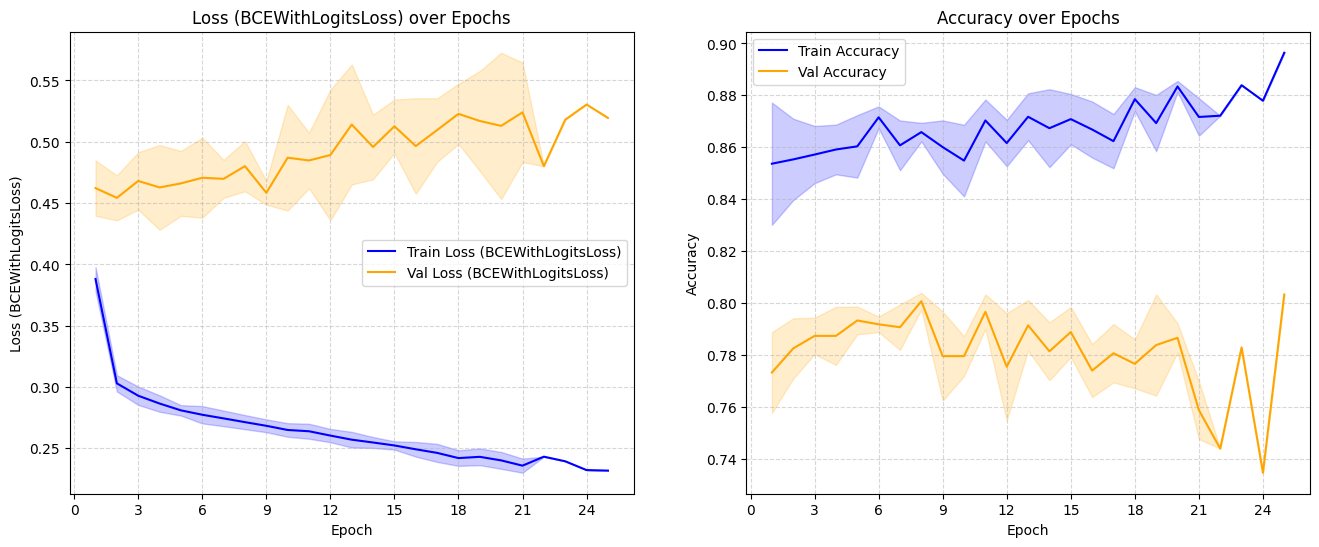

In [15]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task,
    sage_model,
    optimizer,
    criterion,
    device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 6460600


STARTING RUN 1/5


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 11.20it/s]


Epoch 1/30 | Train Loss: 0.4120 | Train accuracy: 0.8732
Epoch 1/30 |   Val Loss: 0.5973 |   Val accuracy: 0.7792
New best model found with Val accuracy: 0.7792


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 12.37it/s]


Epoch 3/30 | Train Loss: 0.3287 | Train accuracy: 0.8635
Epoch 3/30 |   Val Loss: 0.4412 |   Val accuracy: 0.7904
New best model found with Val accuracy: 0.7904


...

Evaluating: 100%|██████████| 3/3 [00:00<00:00, 11.79it/s]


!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 16) !!!


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 13.20it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.871594956203677, 'roc_auc': 0.8663727386677272, 'average_precision': 0.9781222127975258, 'f1': 0.9281714408787421, 'loss': 0.28269513308663424}
Run 5/5 | Final Val Metrics: {'accuracy': 0.8070500927643784, 'roc_auc': 0.8151860744297718, 'average_precision': 0.9376676087987181, 'f1': 0.8790697674418605, 'loss': 0.4831466510587809}
Run 5/5 | Final Test Metrics: {'accuracy': 0.7174556213017751, 'roc_auc': 0.7472789963443005, 'average_precision': 0.8605141801541063, 'f1': 0.811078140454995, 'loss': 0.6785159777607438}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.8716 ± 0.0092
  Roc_auc: 0.8748 ± 0.0314
  Average_precision: 0.9794 ± 0.0065
  F1: 0.9274 ± 0.0051
  Loss: 0.2678 ± 0.0277

[VAL] Metrics:
  Accuracy: 0.7996 ± 0.0089
  Roc_auc: 0.7930 ± 0.0202
  Average_precision: 0.9286 ± 0.0094
  F1: 0.8763 ± 0.0047
  Loss: 0.5138 ± 0.0574

[TEST] Metrics:
  Accuracy: 0.6932 ± 0.0138
  Roc_auc: 0.6909 ± 0.0455
  Average

9

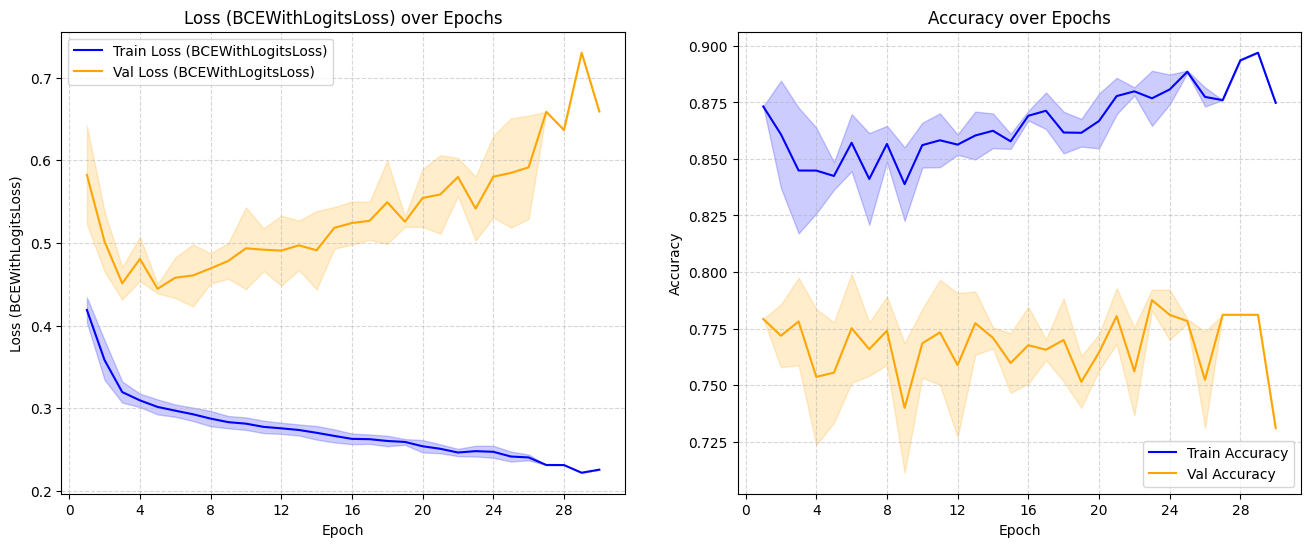

In [16]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()